In [62]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

zip_file_name = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

zip_file_name = ''

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall()

In [5]:
labels_path = '/content/dataset┬áΓÇö ╨║╨╛╨┐╨╕╤Å/legs_positions_labels'
pics_path = '/content/dataset┬áΓÇö ╨║╨╛╨┐╨╕╤Å/legs_positions_pictures'

In [6]:
class SkeletonDataset(Dataset):
    def __init__(self, images_root, coords_root, transform=None, point_transforms=None):
        self.images_root = images_root # пути к изображениям
        self.coords_root = coords_root # пути к координатам
        self.transform = transform # хранит переданные трансформации
        self.point_transforms = point_transforms # хранит переданные трансформации
        self.data = [] # сюда будут записаны пути к изображениям, файлы координат и метки классов
        self.class_to_idx = {} # словарь, сопоставляющий имя класса с индексом

        # Собираем все классы в словарь self.class_to_idx
        for class_name in sorted(os.listdir(images_root)):
            class_path = os.path.join(images_root, class_name)
            if os.path.isdir(class_path): # если элемент — папка,
                self.class_to_idx[class_name] = len(self.class_to_idx) # добавляем имя папки == имя класса в self.class_to_idx с индексом
        # Таким образом, каждому классу присваивается уникальный индекс (0, 1, 2 и т. д.).

        # Рекурсивно обходим папки с изображениями
        for root, _, files in os.walk(images_root):
            for file in files:
                if file.endswith(('.jpeg', '.png')):
                    # Получаем относительный путь к изображению
                    rel_path = os.path.relpath(os.path.join(root, file), images_root)
                    # Получаем путь к файлу с координатами
                    coord_path = os.path.join(coords_root, os.path.splitext(rel_path)[0] + '.txt')
                    # Проверяем, что соответствующий файл с координатами существует
                    if os.path.exists(coord_path):
                        image_path = os.path.join(images_root, rel_path)
                        # Извлекаем метку класса из имени подпапки
                        class_name = rel_path.split(os.sep)[0]
                        label = self.class_to_idx[class_name]
                        self.data.append((image_path, coord_path, label))

    def __len__(self):
        return len(self.data)

    # Загрузка элементов
    def __getitem__(self, idx):
        image_path, coords_path, label = self.data[idx] # получаем пути к изображениям и координатам
        image = Image.open(image_path).convert('RGB') # загружаем изображение и конвертируем сразу в RGB

        # Применяем трансформации к картинкам, если self.transform = True
        if self.transform:
            image = self.transform(image)

        # Загружаем координаты в виде масива numpy
        with open(coords_path, 'r') as f:
            coords = np.loadtxt(f)

        # ширина и высота скелета (разница между максимальным и минимальным значением по осям X и Y)
        width = coords[0,:].max() - coords[0,:].min()
        height = coords[1,:].max() - coords[1,:].min()

        # средние значения координат (центр скелета)
        cx = coords[0,:].mean()
        cy = coords[1,:].mean()

        # ОЛЕГ: Стоит нормализировать исходя из размеров самого скелетона
        coords[:, 0] = (coords[:, 0] - cx) / width  # нормализация широты
        coords[:, 1] = (coords[:, 1] - cy) / height  # нормализация высоты

        # Обрезаем значения в пределах [0, 1]
        coords = np.clip(coords, 0, 1)

        # Преобразуем координаты скелетона в тензор
        coords = torch.tensor(coords, dtype=torch.float32)

        # Если переданы специальные трансформации для координат (point_transforms), применяем их (при transformations = True)
        if self.point_transforms is not None:
            coords = self.point_transforms(coords)

        label = torch.tensor(label, dtype=torch.long) # превращаем метку класса в тензор

        return image, coords, label # получаем тензоры

In [8]:
# transforms.Compose([...]) объединяет несколько преобразований в один пайплайн
transform = transforms.Compose([
    transforms.Resize((256, 256)), # изменяет изображения в меньший формат
    transforms.ToTensor(), # конвертирует изображение из формата PIL или NumPy в тензор PyTorch с диапазоном значений [0, 1] и порядком каналов (C, H, W)
])

In [9]:
dataset = SkeletonDataset(images_root=pics_path,
                          coords_root=labels_path,
                          transform=transform) # передаем трансформацию для изображений

In [10]:
dataloader = torch.utils.data.DataLoader(dataset,
                                         batch_size=32,
                                         shuffle=True) # перемешиваем

In [11]:
# Итерация по dataloader возвращает images, coords и labels для одного батча
for images, coords, labels in dataloader:
    print("Размер изображений:", images.shape)  # размер тензора (batch_size, число цветовых каналов (RGB), 256, 256). последнее - размер изображения
    print("Размер координат:", coords.shape)    # (batch_size, num_nodes, 2). num_nodes — количество ключевых точек скелета, 2 - координаты x,y
    print("Размер меток:", labels.shape)         # (batch_size,) - размер меток классов, 32 (по одной метке на изображение)
    print("Пример меток:", labels[:5])           # Вывод первых 5 меток
    break

Размер изображений: torch.Size([32, 3, 256, 256])
Размер координат: torch.Size([32, 17, 3])
Размер меток: torch.Size([32])
Пример меток: tensor([ 7,  0,  0, 16, 26])


In [13]:
# класс PointCoordsRandomTransform выполняет случайные трансформации координат точек (аугментацию)
class PointCoordsRandomTransform:
    def __init__(self, p_rot=0.5, # вероятность применения поворота
                 rot_range_deg=(-10, 10), # диапазон углов поворота в градусах
                 p_shift=0.5, # вероятность применения сдвига
                 shift=20, # максимальное значение сдвига по x и y
                 p_scale_x=0.5, # вероятность масштабирования по x
                 scale_x=(0.8, 1.2), # диапазон коэффициентов масштабирования по x
                 p_scale_y=0.5, # вероятность масштабирования по y
                 scale_y=(0.8, 1.2)): # диапазон коэффициентов масштабирования по y

        # сохраняем параметры
        self.p_rot = p_rot
        self.rot_range_deg = rot_range_deg
        self.p_shift = p_shift
        self.shift = shift
        self.p_scale_x = p_scale_x
        self.scale_x = scale_x
        self.p_scale_y = p_scale_y
        self.scale_y = scale_y

    # применение трансформации
    def __call__(self, coords):
        coords = coords.clone()  # Создаем копию тензора, чтобы избежать изменения оригинального тензора

        # Разделяем x, y и conf
        xy = coords[:, :2]  # только координаты x, y
        conf = coords[:, -1:]  # только уверенность модели

        # С вероятностью p_rot выполняем поворот
        if np.random.rand() < self.p_rot:
            angle = np.random.uniform(*self.rot_range_deg) # выбираем случайный угол поворота в заданном диапазоне (rot_range_deg)
            angle = np.deg2rad(angle) # переводим угол из градусов в радианы
            # Создаем матрицу поворота
            rot_mat = torch.tensor([[np.cos(angle), -np.sin(angle)],
                                    [np.sin(angle),  np.cos(angle)]], dtype=torch.float32)
            xy = xy @ rot_mat.T  # применяем поворот

        # С вероятностью p_shift выполняем случайный сдвиг
        if np.random.rand() < self.p_shift:
            # генерируем случайное смещение в диапазоне [-shift, shift] для x и y
            shift_val = torch.tensor(np.random.uniform(-self.shift, self.shift, size=(2,)), dtype=torch.float32)
            xy += shift_val # прибавляем shift_val к координатам точек

        # С вероятностью p_scale_x случайно изменяем масштаб по x (умножаем на случайное число из scale_x)
        if np.random.rand() < self.p_scale_x:
            xy[:, 0] *= np.random.uniform(*self.scale_x)

        # Аналогично масштабируем y с вероятностью p_scale_y
        if np.random.rand() < self.p_scale_y:
            xy[:, 1] *= np.random.uniform(*self.scale_y)

        transformed_coords = torch.cat([xy, conf], dim=1)  # склеиваем обратно x, y и conf

        return transformed_coords

In [15]:
transform = PointCoordsRandomTransform()

# собираем данные в numpy массивы
X, y = [], []
for epoch in range(10): # увеличиваем датасет в 10 раз == 10 эпох
    for _, coords, label in dataset: # пропускаем изображение и смотрим только координаты и метки
        # оригинальные координаты
        X.append(coords.view(-1).numpy()) # coords.view(-1) превращает координаты в одномерный тензор
        y.append(label.item()) # превращает тензор-метку в обычное число

        # преображение координат
        transformed_coords = transform(coords)
        X.append(transformed_coords.view(-1).numpy())
        y.append(label.item())

# Превращаем списки X и y в массивы numpy для удобства работы
X = np.array(X)
y = np.array(y)

In [18]:
# Разделяем датасет на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, # 20% данных отправляем в тестовую выборку
                                                    random_state=42) # фиксируем случайное разбиение для воспроизводимости

print("Размеры данных:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Размеры данных:
X_train: (31280, 51)
X_test: (7820, 51)
y_train: (31280,)
y_test: (7820,)


### Пробуем обучить DecisionTreeClassifier

In [19]:
# копируем датасеты для обучения модели
X_train_DecTree, X_test_DecTree, y_train_DecTree, y_test_DecTree = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [23]:
# Инициализация и обучение модели
clf_DecTree = DecisionTreeClassifier(random_state=42) # random_state=42 фиксирует случайность (чтобы результаты были одинаковыми при каждом запуске)
clf_DecTree.fit(X_train_DecTree, y_train_DecTree) # обучаем модель на тренировочных данных

DecisionTreeClassifier(random_state=42)

In [24]:
# Предсказание на тестовой выборке
y_pred_DecTree = clf_DecTree.predict(X_test_DecTree) # результаты сохраняем в y_pred_DecTree

In [25]:
# Оценка точности
accuracy_DecTree = accuracy_score(y_test_DecTree, y_pred_DecTree) # доля правильно предсказанных примеров
print(f"Точность на тестовой выборке: {accuracy_DecTree:.2f}")

Точность на тестовой выборке: 0.87


In [26]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_DecTree, y_pred_DecTree))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1066
           1       0.82      0.79      0.80        90
           2       0.83      0.79      0.81        80
           3       0.90      0.81      0.85        54
           4       0.92      0.73      0.81       104
           5       0.83      0.86      0.84       150
           6       0.88      0.91      0.89       108
           7       0.89      0.88      0.89       918
           8       1.00      1.00      1.00         2
           9       0.83      0.90      0.87       111
          10       0.86      0.88      0.87       373
          11       0.86      0.85      0.85       216
          12       1.00      0.73      0.84        11
          13       0.88      0.88      0.88       281
          14       0.80      0.87      0.83       236
          15       0.85      0.85      0.85        33
          16       0.92      0.90      0.91       992
    

In [29]:
# Матрица ошибок
conf_matrix_DecTree = confusion_matrix(y_test_DecTree, y_pred_DecTree)
print("Матрица ошибок:")
print(conf_matrix_DecTree)

Матрица ошибок:
[[946   2   2   1   1   1   0  22   0   1  10   5   0   4  10   1  17   6
   11   3   2   3   0   2   4   3   2   7   0]
 [  2  71   0   1   0   1   0   6   0   0   1   0   0   1   1   0   0   0
    1   0   1   0   0   0   2   0   0   2   0]
 [  1   2  63   0   0   1   0   0   0   0   4   1   0   0   0   0   2   0
    1   0   1   2   0   0   1   1   0   0   0]
 [  2   0   2  44   0   0   0   1   0   0   0   0   0   0   1   0   0   0
    1   0   0   0   0   0   1   0   2   0   0]
 [  5   1   0   0  76   1   0   6   0   0   1   2   0   1   4   0   2   1
    1   0   0   0   0   1   0   1   0   1   0]
 [  2   0   1   0   0 129   0   2   0   0   0   0   0   1   1   0   1   0
    3   0   0   0   0   2   5   2   1   0   0]
 [  0   0   0   0   0   1  98   2   0   0   2   0   0   0   0   1   1   0
    1   0   0   0   0   0   1   0   0   0   1]
 [ 24   4   0   2   2   2   2 808   0   2   3   0   0   6  10   0   9   1
    8   1   4   3   0   3   7  13   3   1   0]
 [  0   0   0   

In [31]:
# Точность модели на тестовых данных
accuracy_DecTree_test = accuracy_score(y_test_DecTree, y_pred_DecTree)
print(f"Точность на тестовой выборке: {accuracy_DecTree_test:.2f}")

Точность на тестовой выборке: 0.87


In [33]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_DecTree, y_pred_DecTree))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1066
           1       0.82      0.79      0.80        90
           2       0.83      0.79      0.81        80
           3       0.90      0.81      0.85        54
           4       0.92      0.73      0.81       104
           5       0.83      0.86      0.84       150
           6       0.88      0.91      0.89       108
           7       0.89      0.88      0.89       918
           8       1.00      1.00      1.00         2
           9       0.83      0.90      0.87       111
          10       0.86      0.88      0.87       373
          11       0.86      0.85      0.85       216
          12       1.00      0.73      0.84        11
          13       0.88      0.88      0.88       281
          14       0.80      0.87      0.83       236
          15       0.85      0.85      0.85        33
          16       0.92      0.90      0.91       992
    

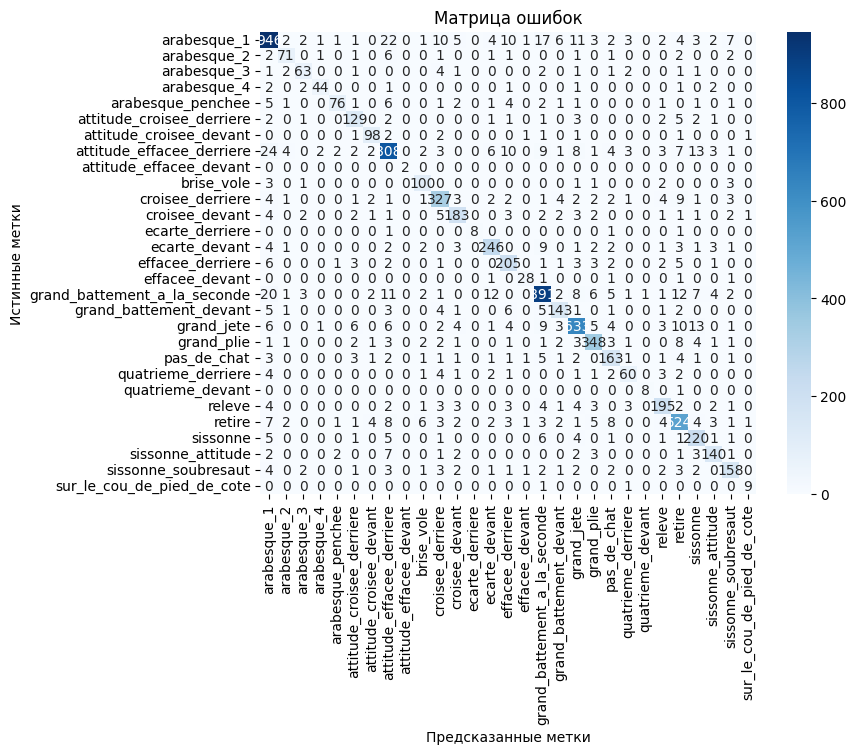

In [35]:
from sklearn.metrics import confusion_matrix

# Матрица ошибок
conf_matrix_DecTree = confusion_matrix(y_test_DecTree, y_pred_DecTree)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_DecTree, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

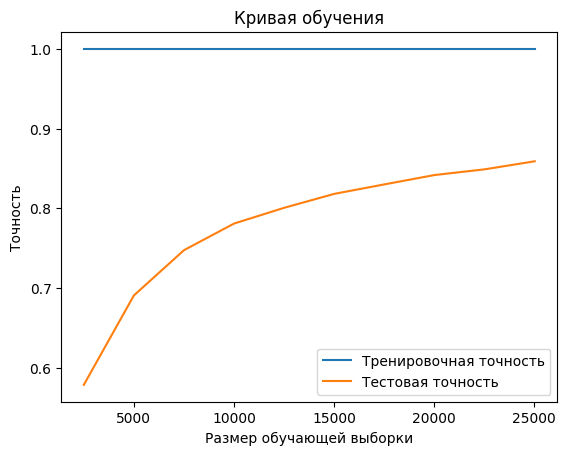

In [38]:
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier

# Я ВООБЩЕ НЕ ПОНИМАЮ, ЧТО ТУТ ПРОИСХОДИТ

# Используем learning_curve для отслеживания точности на разных размерах выборки
train_sizes_DecTree, train_scores_DecTree, test_scores_DecTree = learning_curve(
    clf_DecTree, # модель, которую будем обучать
    X_train_DecTree,
    y_train_DecTree,
    cv=5, # кросс-валидация с 5 фолдами (данные делятся на 5 частей, и модель обучается 5 раз)
    n_jobs=-1, # использует все доступные процессоры для параллельных вычислений
    train_sizes=np.linspace(0.1, 1.0, 10) # задает массив размеров обучающих выборок от 10% до 100% от общего объема данных (в 10 точках)
                                                                                )
# Функция learning_curve возвращает:
# 	•	train_sizes_DecTree: размеры обучающих выборок.
# 	•	train_scores_DecTree: точности на тренировочных данных для каждого размера обучающей выборки.
# 	•	test_scores_DecTree: точности на тестовых данных для каждого размера обучающей выборки.

# Средние значения точности на тренировочных и тестовых данных
train_mean_DecTree = np.mean(train_scores_DecTree, axis=1)
test_mean_DecTree = np.mean(test_scores_DecTree, axis=1)

# Визуализация кривых обучения
plt.plot(train_sizes_DecTree, train_mean_DecTree, label="Тренировочная точность")
plt.plot(train_sizes_DecTree, test_mean_DecTree, label="Тестовая точность")
plt.xlabel('Размер обучающей выборки')
plt.ylabel('Точность')
plt.title('Кривая обучения')
plt.legend()
plt.show()

In [39]:
clf_DecTree.fit(X_train_DecTree, y_train_DecTree)

DecisionTreeClassifier(random_state=42)

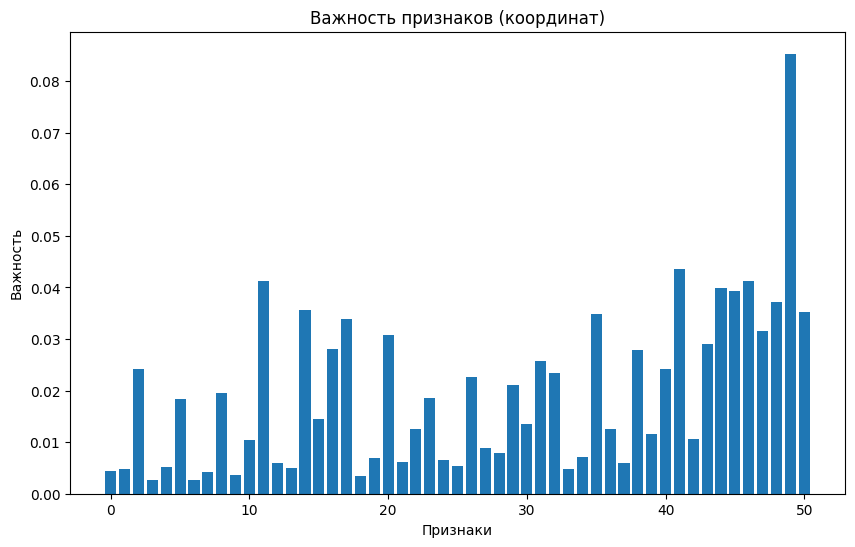

In [40]:
# Визуализация важности признаков
feature_importance_DecTree = clf_DecTree.feature_importances_

# ОТКУДА ЭТИ ПРИЗНАКИ? КАК ПОНЯТЬ, ЧТО МОДЕЛЬ ОЦЕНИВАЕТ?

# Отображаем важность признаков
plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), feature_importance_DecTree)
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.title('Важность признаков (координат)')
plt.show()

In [41]:
# import joblib

# # Сохраняем модель в файл
# model_filename = 'skeleton_classifier.pkl'
# joblib.dump(clf, model_filename)

# print(f"Модель сохранена в файле: {model_filename}")

Когда нужно использовать модель для предсказаний на новых данных:

In [43]:
# # Загружаем модель из файла
# loaded_model = joblib.load(model_filename)

# # Проверка работы загруженной модели
# y_pred = loaded_model.predict(X_test)
# print("Точность загруженной модели:", accuracy_score(y_test, y_pred))

Визуализация дерева решений:

Деревья решений легко интерпретировать, поэтому полезно их визуализировать.

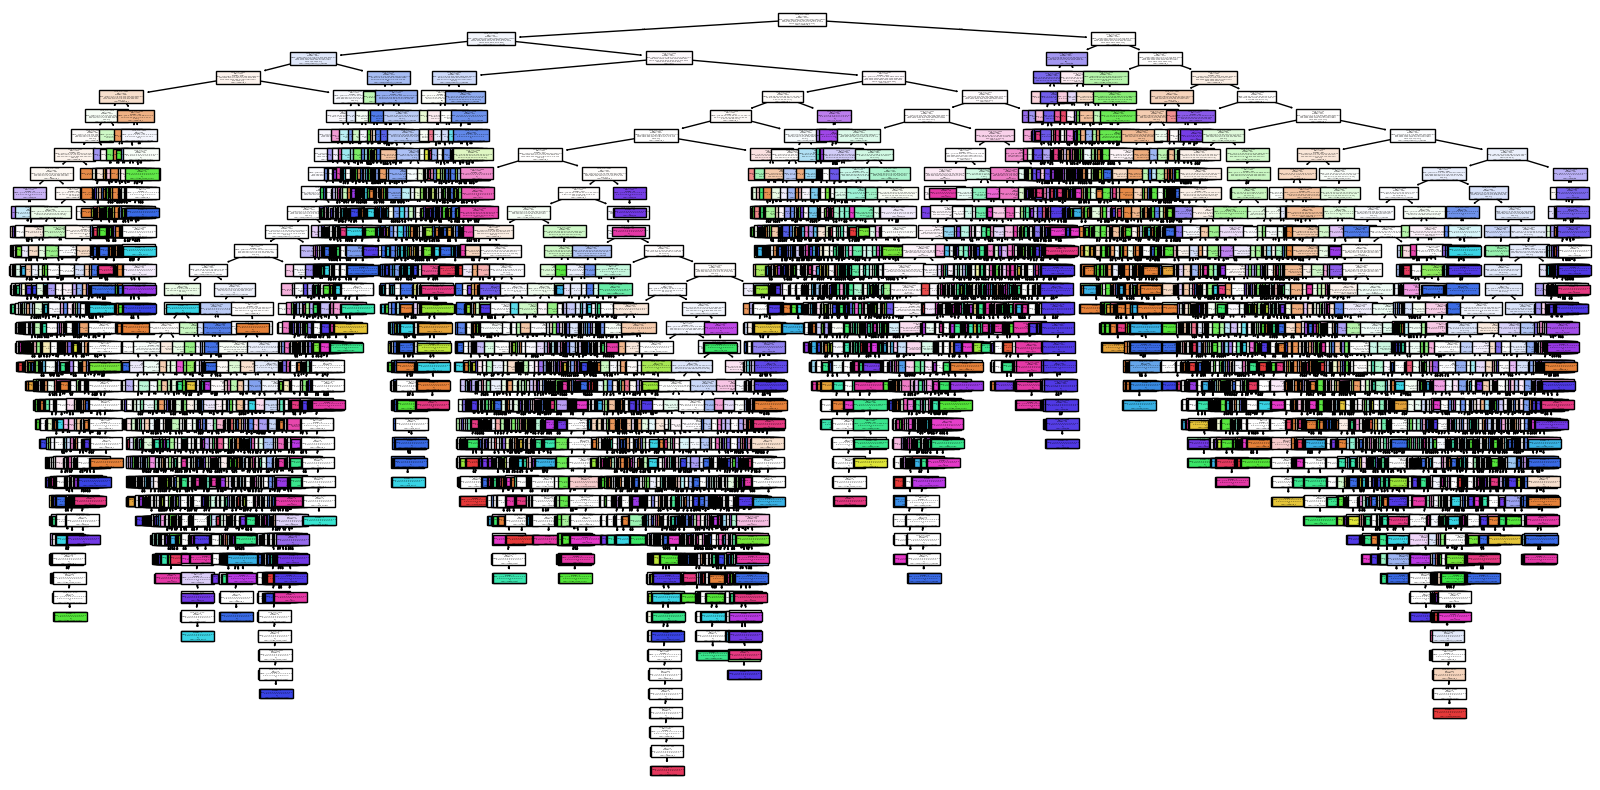

In [44]:
# Визуализация дерева решений
plt.figure(figsize=(20, 10))
tree.plot_tree(clf_DecTree,
               feature_names=[f"coord_{i}" for i in range(X.shape[1])],
               class_names=[str(c) for c in dataset.class_to_idx.keys()],
               filled=True)
plt.show()

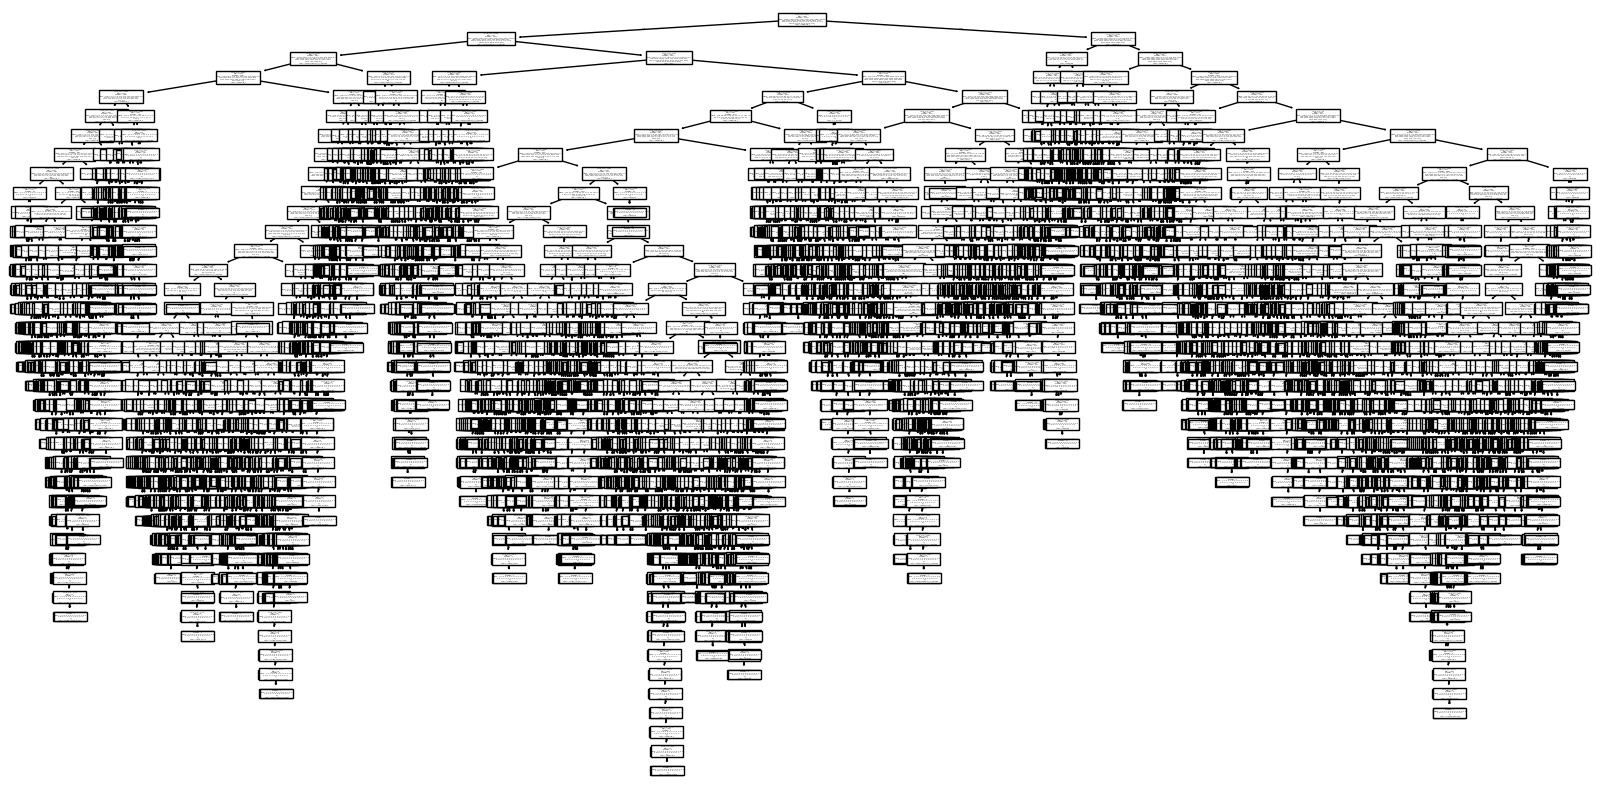

In [45]:
# Визуализация дерева решений
plt.figure(figsize=(20, 10))
tree.plot_tree(clf_DecTree,
               feature_names=[f"coord_{i}" for i in range(X.shape[1])],
               class_names=[str(c) for c in dataset.class_to_idx.keys()],
               filled=False)
plt.show()

### Пробуем обучить SVC

In [46]:
# копируем датасеты для обучения модели
X_train_SVC, X_test_SVC, y_train_SVC, y_test_SVC = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [50]:
from sklearn.svm import SVC

# Инициализация и обучение модели
clf_SVC = SVC(kernel='rbf', random_state=42)
clf_SVC.fit(X_train_SVC, y_train_SVC)

SVC(random_state=42)

In [51]:
# Предсказание на тестовой выборке
y_pred_SVC = clf_SVC.predict(X_test_SVC)

In [52]:
# Оценка точности
accuracy_SVC = accuracy_score(y_test_SVC, y_pred_SVC)
print(f"Точность на тестовой выборке: {accuracy_SVC:.2f}")

Точность на тестовой выборке: 0.23


In [53]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_SVC, y_pred_SVC))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.16      0.60      0.25      1066
           1       0.00      0.00      0.00        90
           2       0.00      0.00      0.00        80
           3       0.00      0.00      0.00        54
           4       0.00      0.00      0.00       104
           5       0.00      0.00      0.00       150
           6       0.00      0.00      0.00       108
           7       0.31      0.36      0.33       918
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00       111
          10       0.27      0.17      0.21       373
          11       0.00      0.00      0.00       216
          12       0.00      0.00      0.00        11
          13       0.00      0.00      0.00       281
          14       0.00      0.00      0.00       236
          15       0.00      0.00      0.00        33
          16       0.29      0.58      0.39       992
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
# Матрица ошибок
conf_matrix_SVC = confusion_matrix(y_test_SVC, y_pred_SVC)
print("Матрица ошибок:")
print(conf_matrix_SVC)

Матрица ошибок:
[[642   0   0   0   0   0   0 114   0   0   6   0   0   0   0   0 281   0
   23   0   0   0   0   0   0   0   0   0   0]
 [ 16   0   0   0   0   0   0  54   0   0   1   0   0   0   0   0  12   0
    7   0   0   0   0   0   0   0   0   0   0]
 [ 38   0   0   0   0   0   0   7   0   0   2   0   0   0   0   0  31   0
    2   0   0   0   0   0   0   0   0   0   0]
 [ 15   0   0   0   0   0   0  14   0   0   3   0   0   0   0   0  21   0
    1   0   0   0   0   0   0   0   0   0   0]
 [ 40   0   0   0   0   0   0  26   0   0   0   0   0   0   0   0  35   0
    3   0   0   0   0   0   0   0   0   0   0]
 [ 76   0   0   0   0   0   0  10   0   0  15   0   0   0   0   0  47   0
    2   0   0   0   0   0   0   0   0   0   0]
 [ 43   0   0   0   0   0   0   3   0   0  30   0   0   0   0   0  31   0
    0   0   0   0   0   0   1   0   0   0   0]
 [371   0   0   0   0   0   0 330   0   0   0   0   0   0   0   0 194   0
   23   0   0   0   0   0   0   0   0   0   0]
 [  1   0   0   

In [56]:
# Точность модели на тестовых данных
accuracy_SVC_test = accuracy_score(y_test_SVC, y_pred_SVC)
print(f"Точность на тестовой выборке: {accuracy_SVC_test:.2f}")

Точность на тестовой выборке: 0.23


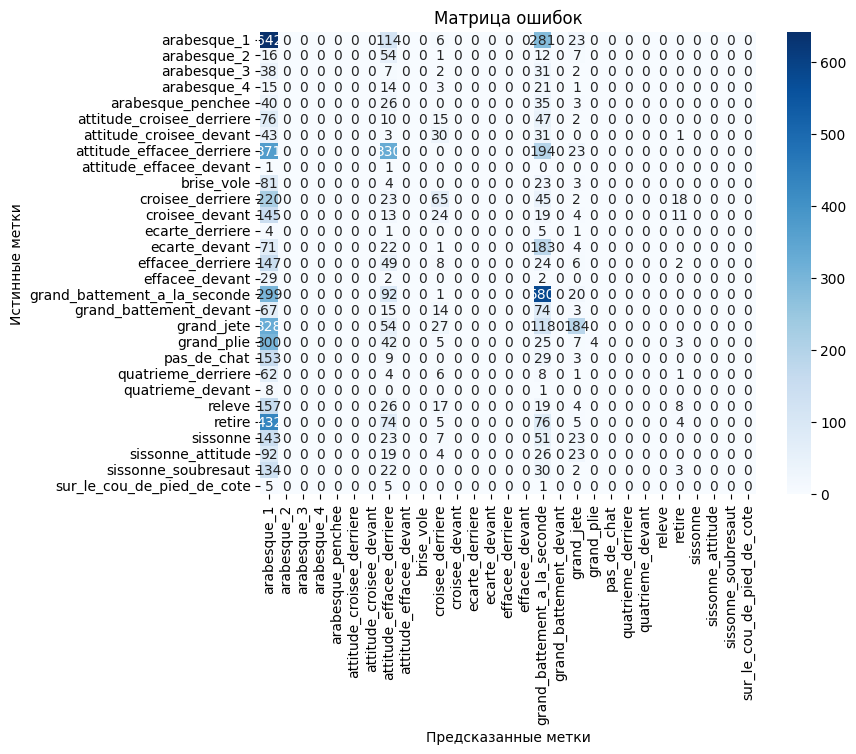

In [57]:
# Матрица ошибок
conf_matrix_SVC = confusion_matrix(y_test_SVC, y_pred_SVC)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_SVC, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Пробуем обучить RandomForestClassifier

In [58]:
X_train_RandFor, X_test_RandFor, y_train_RandFor, y_test_RandFor = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [59]:
from sklearn.ensemble import RandomForestClassifier

# Инициализация и обучение модели
clf_RandFor = RandomForestClassifier(random_state=42)
clf_RandFor.fit(X_train_RandFor, y_train_RandFor)

RandomForestClassifier(random_state=42)

In [67]:
# Предсказание на тестовой выборке
y_pred_RandFor = clf_RandFor.predict(X_test_RandFor)

In [68]:
# Оценка точности
accuracy_RandFor = accuracy_score(y_test_RandFor, y_pred_RandFor)
print(f"Точность на тестовой выборке: {accuracy_RandFor:.2f}")

Точность на тестовой выборке: 0.95


In [69]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_RandFor, y_pred_RandFor))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1066
           1       1.00      0.84      0.92        90
           2       0.99      0.89      0.93        80
           3       1.00      0.91      0.95        54
           4       1.00      0.80      0.89       104
           5       0.97      0.92      0.94       150
           6       1.00      0.95      0.98       108
           7       0.90      0.99      0.94       918
           8       1.00      1.00      1.00         2
           9       1.00      0.94      0.97       111
          10       0.95      0.95      0.95       373
          11       0.99      0.93      0.96       216
          12       1.00      0.91      0.95        11
          13       1.00      0.92      0.96       281
          14       1.00      0.94      0.97       236
          15       1.00      0.91      0.95        33
          16       0.92      0.99      0.95       992
    

In [70]:
# Матрица ошибок
conf_matrix_RandFor = confusion_matrix(y_test_RandFor, y_pred_RandFor)
print("Матрица ошибок:")
print(conf_matrix_RandFor)

Матрица ошибок:
[[1041    0    0    0    0    0    0   14    0    0    0    0    0    0
     0    0    8    0    2    0    0    0    0    0    1    0    0    0
     0]
 [   0   76    0    0    0    0    0   11    0    0    0    0    0    0
     0    0    1    0    1    0    0    0    0    0    0    0    1    0
     0]
 [   4    0   71    0    0    1    0    4    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   2    0    0   49    0    0    0    2    0    0    0    0    0    0
     0    0    1    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   8    0    0    0   83    0    0    5    0    0    2    1    0    0
     0    0    5    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   3    0    1    0    0  138    0    4    0    0    2    0    0    0
     0    0    1    0    1    0    0    0    0    0    0    0    0    0
     0]
 [   2    0    0    0    0    0  103    1    0    0    1    0    0    0


In [71]:
# Точность модели на тестовых данных
accuracy_RandFor_test = accuracy_score(y_test_RandFor, y_pred_RandFor)
print(f"Точность на тестовой выборке: {accuracy_RandFor_test:.2f}")

Точность на тестовой выборке: 0.95


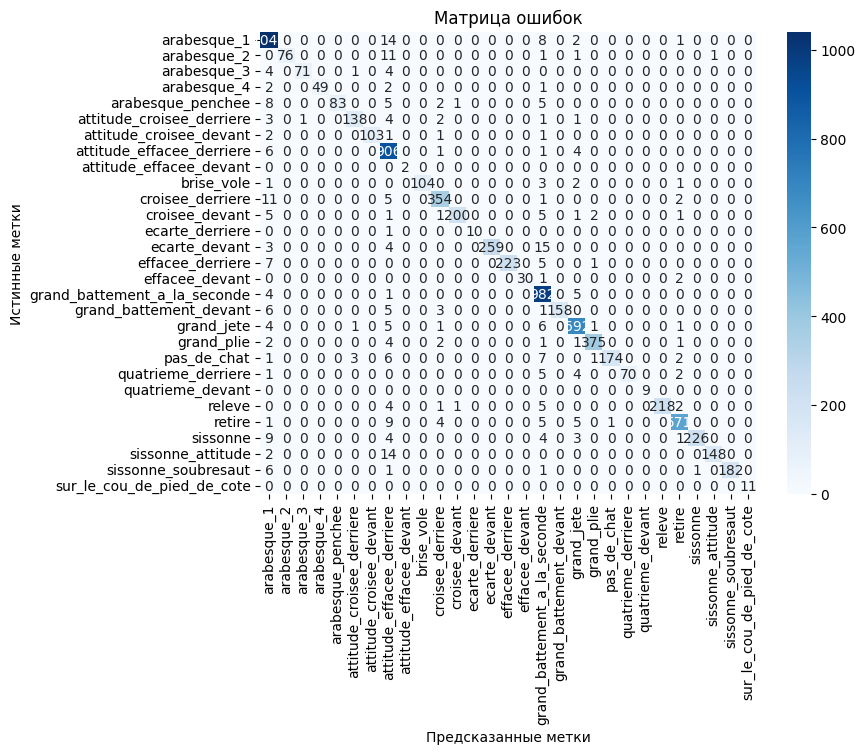

In [72]:
# Матрица ошибок
conf_matrix_RandFor = confusion_matrix(y_test_RandFor, y_pred_RandFor)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_RandFor, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Попробуем обучить AdaBoostClassifier

In [73]:
X_train_AdaBo, X_test_AdaBo, y_train_AdaBo, y_test_AdaBo = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [74]:
from sklearn.ensemble import AdaBoostClassifier

# Инициализация и обучение модели
clf_AdaBo = AdaBoostClassifier(random_state=42)
clf_AdaBo.fit(X_train_AdaBo, y_train_AdaBo)

AdaBoostClassifier(random_state=42)

In [75]:
# Предсказание на тестовой выборке
y_pred_AdaBo = clf_AdaBo.predict(X_test_AdaBo)

In [76]:
# Оценка точности
accuracy_AdaBo = accuracy_score(y_test_AdaBo, y_pred_AdaBo)
print(f"Точность на тестовой выборке: {accuracy_AdaBo:.2f}")

Точность на тестовой выборке: 0.25


In [77]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_AdaBo, y_pred_AdaBo))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.38      0.26      0.31      1066
           1       0.00      0.00      0.00        90
           2       0.00      0.00      0.00        80
           3       0.00      0.00      0.00        54
           4       0.00      0.00      0.00       104
           5       0.00      0.00      0.00       150
           6       0.00      0.00      0.00       108
           7       0.32      0.51      0.39       918
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00       111
          10       0.18      0.36      0.24       373
          11       0.00      0.00      0.00       216
          12       0.00      0.00      0.00        11
          13       0.00      0.00      0.00       281
          14       0.00      0.00      0.00       236
          15       0.00      0.00      0.00        33
          16       0.19      0.59      0.29       992
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [79]:
# Матрица ошибок
conf_matrix_AdaBo = confusion_matrix(y_test_AdaBo, y_pred_AdaBo)
print("Матрица ошибок:")
print(conf_matrix_AdaBo)

Матрица ошибок:
[[281   0   0   0   0   0   0 169   0   0  57   5   0   0   0   0 315   0
  181   1   0   0   0   0  30  27   0   0   0]
 [  1   0   0   0   0   0   0  52   0   0   2   0   0   0   0   0  22   0
    4   0   0   0   0   0   8   1   0   0   0]
 [  0   0   0   0   0   0   0   8   0   0   6   0   0   0   4   0  38   0
   10   0   0   0   0   0  12   2   0   0   0]
 [  5   0   0   0   0   0   0   7   0   0   1   2   0   0   0   0  28   0
    2   0   0   0   0   0   9   0   0   0   0]
 [  4   0   0   0   0   0   0  14   0   0   4   0   0   0   0   0  69   0
   11   0   0   0   0   0   0   2   0   0   0]
 [  1   0   0   0   0   0   0  27   0   0  16   0   0   8   0   0  80   0
   14   0   0   0   0   0   4   0   0   0   0]
 [  4   0   0   0   0   0   0   7   0   0   6   0   0   0   0   0  68   0
    6   0   0   0   0   0  17   0   0   0   0]
 [ 67   0   0   0   0   0   0 465   0   0  28   0   0   2   0   0 126   0
  184   0   0   0   0   0  30  16   0   0   0]
 [  0   0   0   

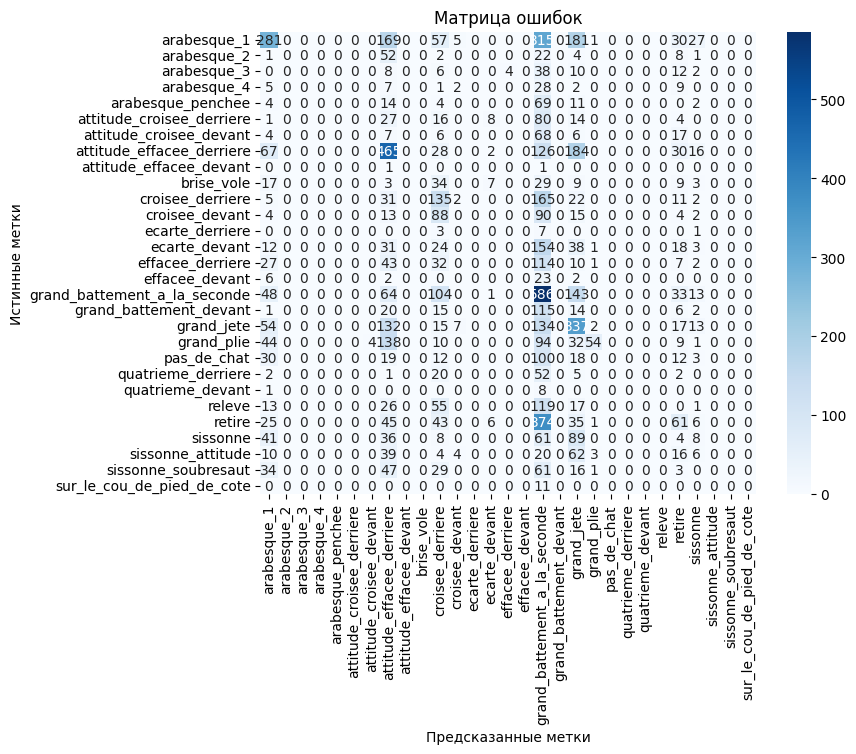

In [80]:
# Матрица ошибок
conf_matrix_AdaBo = confusion_matrix(y_test_AdaBo, y_pred_AdaBo)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_AdaBo, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Попробуем обучить KNeighborsClassifier

In [84]:
X_train_KN, X_test_KN, y_train_KN, y_test_KN = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [85]:
from sklearn.neighbors import KNeighborsClassifier

# Инициализация и обучение модели
clf_KN = KNeighborsClassifier()
clf_KN.fit(X_train_KN, y_train_KN)

KNeighborsClassifier()

In [86]:
# Предсказание на тестовой выборке
y_pred_KN = clf_KN.predict(X_test_KN)

In [87]:
# Оценка точности
accuracy_KN = accuracy_score(y_test_KN, y_pred_KN)
print(f"Точность на тестовой выборке: {accuracy_KN:.2f}")

Точность на тестовой выборке: 0.78


In [88]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_KN, y_pred_KN))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.61      0.85      0.71      1066
           1       0.64      0.70      0.67        90
           2       0.69      0.71      0.70        80
           3       0.80      0.72      0.76        54
           4       0.70      0.66      0.68       104
           5       0.70      0.78      0.74       150
           6       0.64      0.81      0.72       108
           7       0.71      0.79      0.75       918
           8       0.67      1.00      0.80         2
           9       0.80      0.74      0.77       111
          10       0.77      0.76      0.77       373
          11       0.80      0.75      0.77       216
          12       1.00      0.55      0.71        11
          13       0.89      0.75      0.81       281
          14       0.89      0.75      0.81       236
          15       0.81      0.76      0.78        33
          16       0.80      0.78      0.79       992
    

In [89]:
# Матрица ошибок
conf_matrix_KN = confusion_matrix(y_test_KN, y_pred_KN)
print("Матрица ошибок:")
print(conf_matrix_KN)

Матрица ошибок:
[[901   6   3   2   4   8   6  37   0   3   9   7   0   4   7   1  19   0
   23   6   0   1   0   1  12   4   0   2   0]
 [  9  63   0   0   1   0   2   8   0   0   0   0   0   0   0   0   1   0
    6   0   0   0   0   0   0   0   0   0   0]
 [ 15   1  57   0   0   0   0   4   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   1   0   1   0   0]
 [  9   1   0  39   0   0   3   1   0   0   0   0   0   0   0   0   0   0
    0   1   0   0   0   0   0   0   0   0   0]
 [ 11   1   0   0  69   1   0  10   0   1   2   0   0   0   1   0   5   0
    2   1   0   0   0   0   0   0   0   0   0]
 [ 12   1   3   0   2 117   1   5   0   2   1   0   0   0   0   0   5   0
    0   1   0   0   0   0   0   0   0   0   0]
 [  5   0   0   0   0   1  88   8   0   1   1   0   0   0   0   0   1   0
    1   0   0   0   0   0   1   1   0   0   0]
 [ 77   4   3   1   5   4   7 722   0   1   7   3   0   3   1   1  36   0
   21   4   2   0   0   4   6   3   1   2   0]
 [  0   0   0   

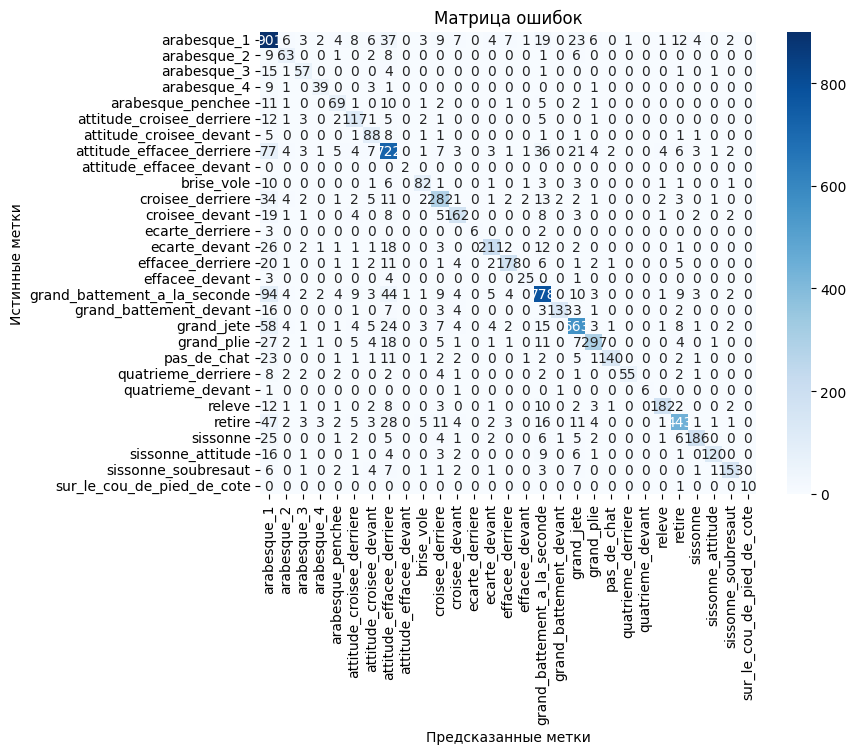

In [90]:
# Матрица ошибок
conf_matrix_KN = confusion_matrix(y_test_KN, y_pred_KN)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_KN, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Попробуем обучить GaussianNB

In [91]:
X_train_GNB, X_test_GNB, y_train_GNB, y_test_GNB = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [92]:
from sklearn.naive_bayes import GaussianNB

# Инициализация и обучение модели
clf_GNB = GaussianNB()
clf_GNB.fit(X_train_GNB, y_train_GNB)

GaussianNB()

In [93]:
# Предсказание на тестовой выборке
y_pred_GNB = clf_GNB.predict(X_test_GNB)

In [94]:
# Оценка точности
accuracy_GNB = accuracy_score(y_test_GNB, y_pred_GNB)
print(f"Точность на тестовой выборке: {accuracy_GNB:.2f}")

Точность на тестовой выборке: 0.11


### Попробуем обучить GradientBoostingClassifier

In [95]:
X_train_GBoo, X_test_GBoo, y_train_GBoo, y_test_GBoo = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [98]:
from sklearn.ensemble import GradientBoostingClassifier

# Инициализация и обучение модели
# clf_GBoo = GradientBoostingClassifier()
clf_GBoo = GradientBoostingClassifier(n_estimators=100,
                                      learning_rate=1.0,
                                      max_depth=1,
                                      random_state=0)

clf_GBoo.fit(X_train_GBoo, y_train_GBoo)

GradientBoostingClassifier(learning_rate=1.0, max_depth=1, random_state=0)

In [99]:
# Предсказание на тестовой выборке
y_pred_GBoo = clf_GBoo.predict(X_test_GBoo)

In [100]:
# Оценка точности
accuracy_GBoo = accuracy_score(y_test_GBoo, y_pred_GBoo)
print(f"Точность на тестовой выборке: {accuracy_GBoo:.2f}")

Точность на тестовой выборке: 0.13


Оно училось 10 минут -- и такой результат...

### Попробуем обучить ExtraTreesClassifier

In [103]:
X_train_ExTree, X_test_ExTree, y_train_ExTree, y_test_ExTree = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [106]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.datasets import make_classification

X_train_ExTree, y_train_ExTree = make_classification(n_features=51,
                                                     random_state=42)
clf_ExTree = ExtraTreesClassifier(n_estimators=100,
                                  random_state=0)
clf_ExTree.fit(X_train_ExTree, y_train_ExTree)

ExtraTreesClassifier(random_state=0)

In [107]:
# Предсказание на тестовой выборке
y_pred_ExTree = clf_ExTree.predict(X_test_ExTree)

In [108]:
# Оценка точности
accuracy_ExTree = accuracy_score(y_test_ExTree, y_pred_ExTree)
print(f"Точность на тестовой выборке: {accuracy_ExTree:.2f}")

Точность на тестовой выборке: 0.03
